In [1]:
# Install required libraries

!pip -q install opencv-python-headless matplotlib kaggle

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"suparnaneupane","key":"6f8089771e611cc773601f9ce18a4d12"}'}

In [3]:
import os
import zipfile

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
# Example Fruits360 download

!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.52G/6.52G [01:12<00:00, 96.6MB/s]



In [5]:
with zipfile.ZipFile("fruits.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,8)

# Helper Functions

The following helper functions are reused throughout the notebook.

In [7]:
def read_rgb(path):
    """
    Read image using OpenCV and convert BGR to RGB.
    """
    img = cv.imread(path)

    if img is None:
        raise FileNotFoundError(path)

    return cv.cvtColor(img, cv.COLOR_BGR2RGB)

In [8]:
def show(title, image, cmap=None):
    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [9]:
def show_many(images, titles, cmap=None):

    n = len(images)

    plt.figure(figsize=(5*n,5))

    for i in range(n):

        plt.subplot(1,n,i+1)

        if cmap is None:
            plt.imshow(images[i])
        else:
            plt.imshow(images[i], cmap=cmap)

        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [10]:
def safe_imwrite(filename, image):
    """
    Save RGB or grayscale image correctly.
    """

    if len(image.shape)==3:
        bgr = cv.cvtColor(image, cv.COLOR_RGB2BGR)
        cv.imwrite(filename, bgr)
    else:
        cv.imwrite(filename, image)

    print(f"Saved: {filename}")

In [11]:
def rgb_to_hsv(image):
    return cv.cvtColor(image, cv.COLOR_RGB2HSV)

In [12]:
def bgr_to_rgb(image):
    return cv.cvtColor(image, cv.COLOR_BGR2RGB)

In [13]:
def display_bgr_vs_rgb(path):

    bgr = cv.imread(path)
    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(bgr)
    plt.title("Raw BGR")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(rgb)
    plt.title("Converted RGB")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

---

# Part A

## Color Space & Fruit Segmentation

This section investigates how HSV color space can be used for robust fruit segmentation under varying illumination conditions.

The following tasks will be completed:

1. RGB vs BGR visualization
2. HSV conversion
3. HSV channel visualization
4. HSV masking
5. HSV threshold selection
6. Brightness and contrast adjustment
7. Reflection

In [32]:
BASE = "/content/dataset/fruits-360_100x100/fruits-360/Training"

In [33]:
from pathlib import Path
import glob

BASE = "/content/dataset/fruits-360_100x100/fruits-360/Training"

def first_image(folder):
    files = sorted(glob.glob(f"{BASE}/{folder}/*.jpg"))
    if not files:
        raise FileNotFoundError(f"No images found in {folder}")
    return files[0]

RED_APPLE = first_image("Apple Red 1")
GREEN_APPLE = first_image("Apple Granny Smith 1")
BANANA = first_image("Banana 1")
STRAWBERRY = first_image("Strawberry 1")
ORANGE = first_image("Orange 1")
LIME = first_image("Limes 1")

print("Dataset paths loaded successfully.")

Dataset paths loaded successfully.


In [34]:
image_path = RED_APPLE

bgr = cv.imread(image_path)

if bgr is None:
    raise FileNotFoundError(image_path)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

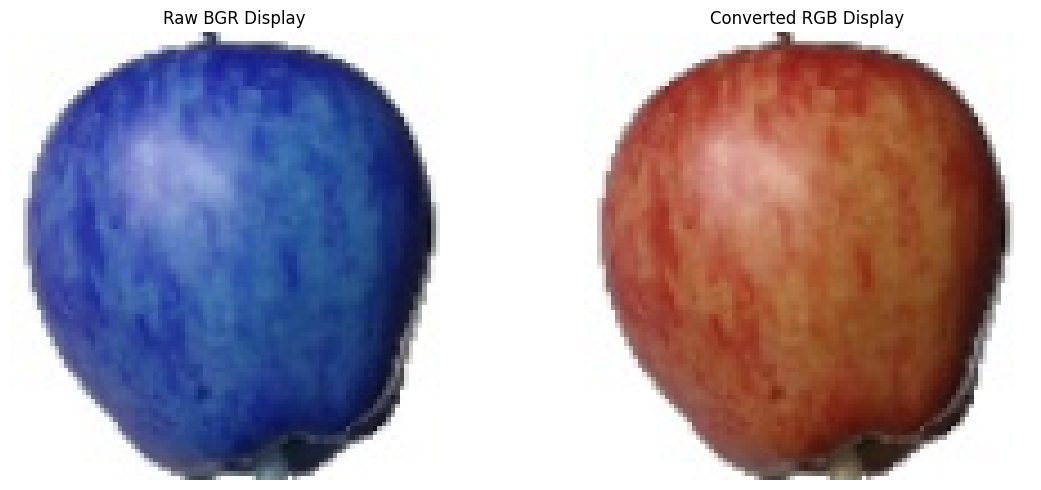

In [35]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(bgr)
plt.title("Raw BGR Display")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb)
plt.title("Converted RGB Display")
plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

OpenCV loads images in **BGR** format, while Matplotlib assumes images are in **RGB** format. Displaying the BGR image directly results in incorrect colors because the red and blue channels are swapped. After conversion to RGB, the apple appears with its correct natural colors.

In [36]:
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

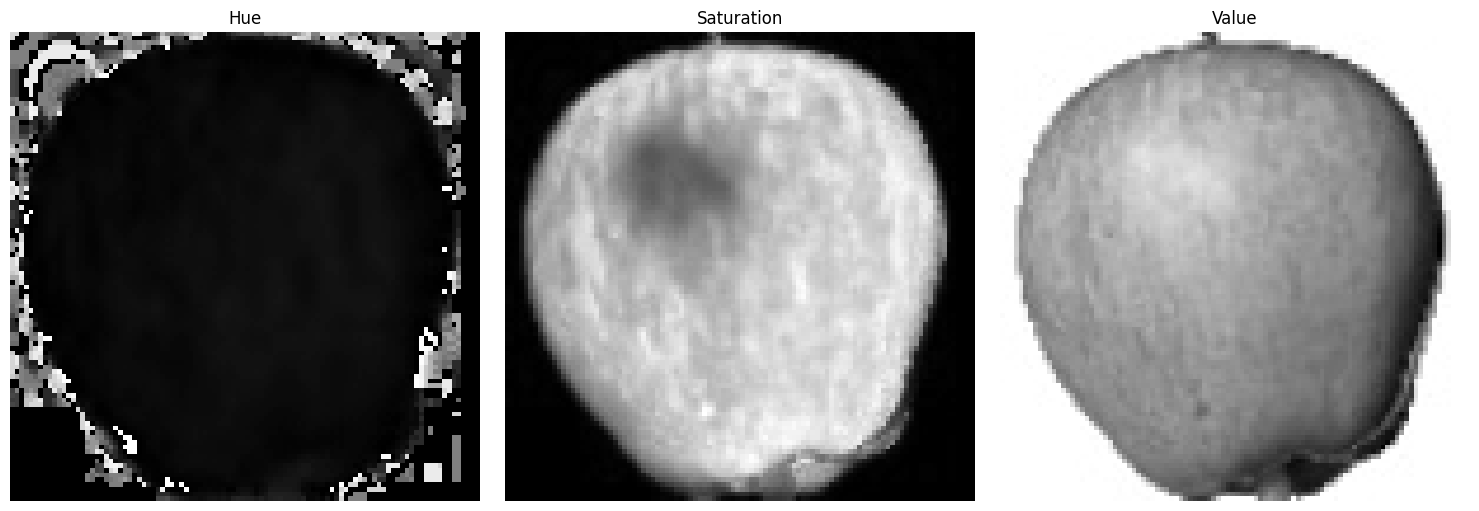

In [37]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

- **Hue (H):** Represents the actual color of the pixels.
- **Saturation (S):** Represents the intensity or purity of the color.
- **Value (V):** Represents the brightness of the image.

For the Fruits-360 images, the **Saturation channel** generally provides the clearest separation between the fruit and the white background because the fruit has highly saturated colors while the background has very low saturation.

In [38]:
lower_red1 = np.array([0, 100, 70])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 100, 70])
upper_red2 = np.array([180, 255, 255])

In [39]:
mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)

mask = cv.bitwise_or(mask1, mask2)

segmented = cv.bitwise_and(rgb, rgb, mask=mask)

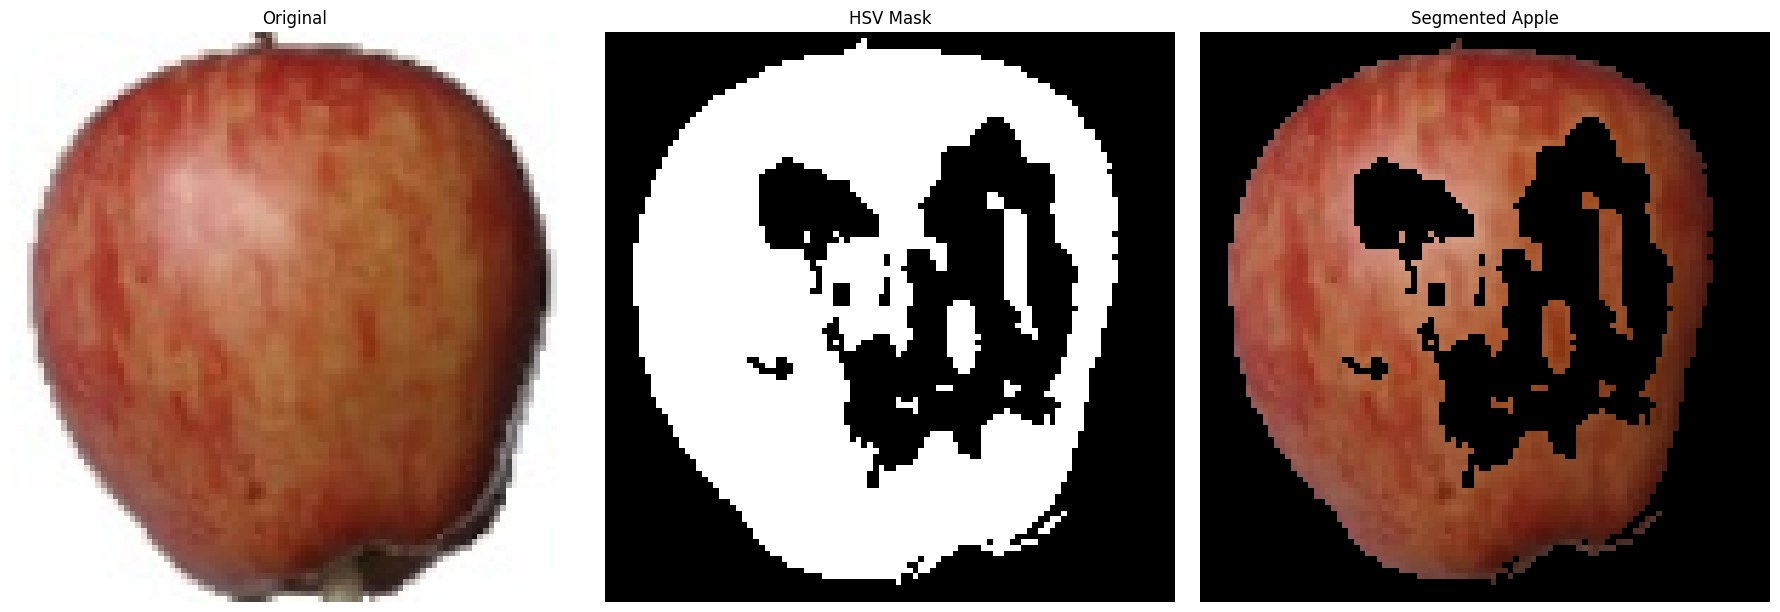

In [40]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("HSV Mask")

plt.subplot(1,3,3)
plt.imshow(segmented)
plt.title("Segmented Apple")

for i in range(1,4):
    plt.subplot(1,3,i)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [41]:
def segment_hsv(image_path, lower, upper):
    bgr = cv.imread(image_path)

    if bgr is None:
        raise FileNotFoundError(image_path)

    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

    mask = cv.inRange(hsv, lower, upper)
    result = cv.bitwise_and(rgb, rgb, mask=mask)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("HSV Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(result)
    plt.title("Segmented")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [43]:
GREEN_LOWER = np.array([35, 40, 40])
GREEN_UPPER = np.array([90, 255, 255])

YELLOW_LOWER = np.array([18, 80, 80])
YELLOW_UPPER = np.array([40, 255, 255])

LIME_LOWER = np.array([35, 50, 50])
LIME_UPPER = np.array([90, 255, 255])

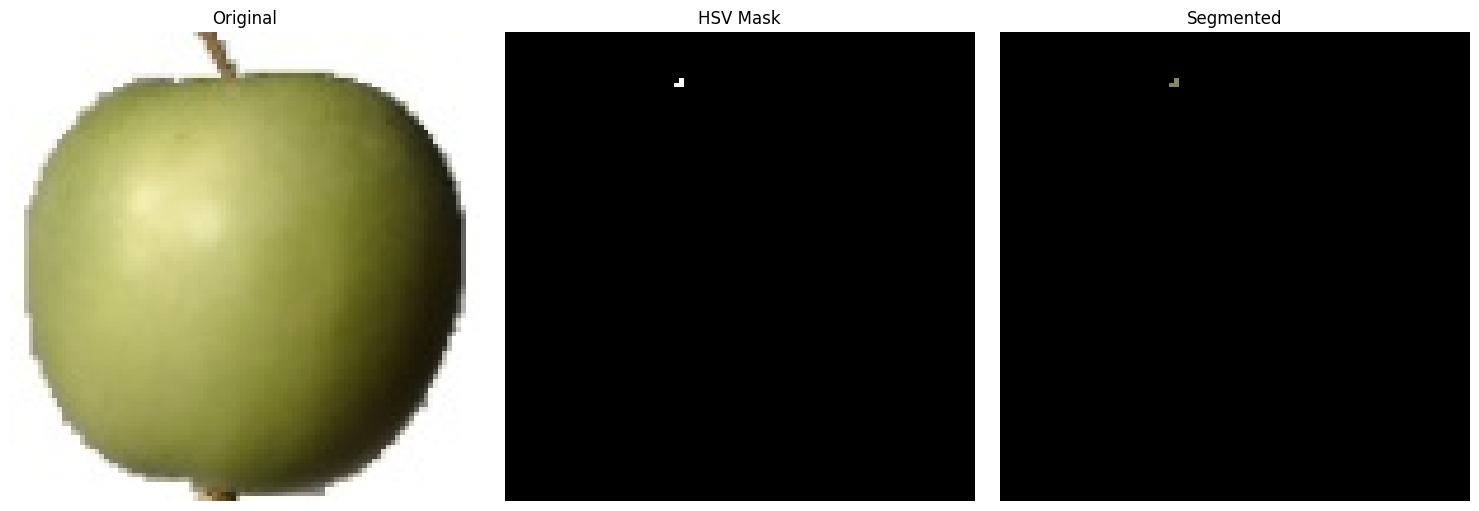

In [44]:
segment_hsv(GREEN_APPLE, GREEN_LOWER, GREEN_UPPER)

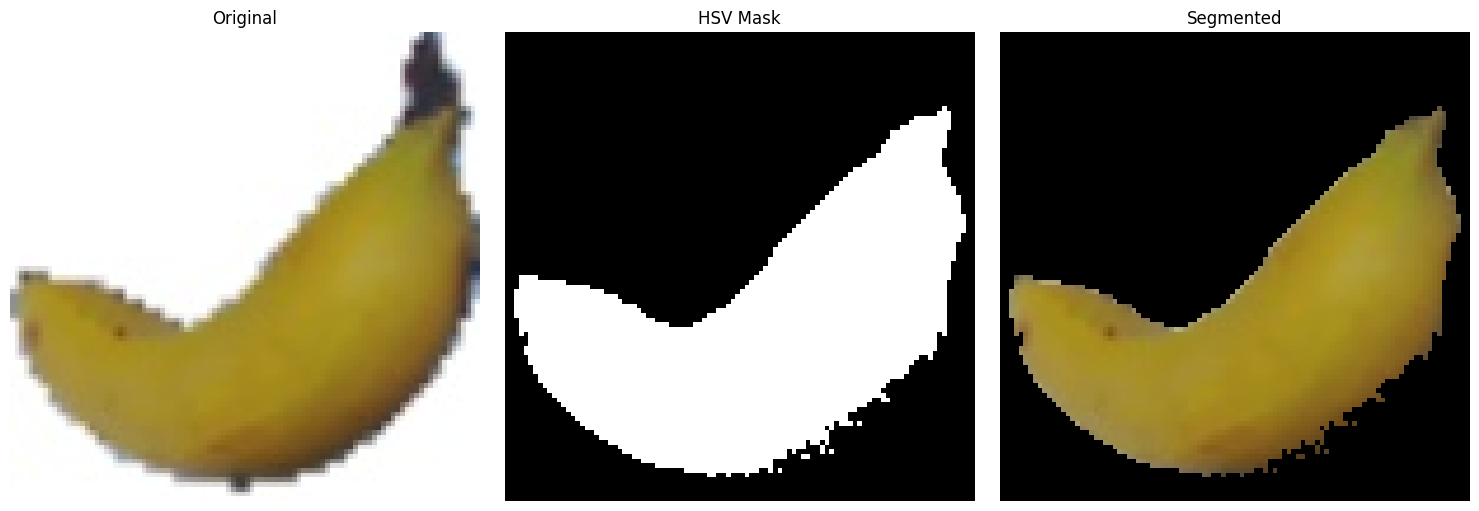

In [45]:
segment_hsv(BANANA, YELLOW_LOWER, YELLOW_UPPER)

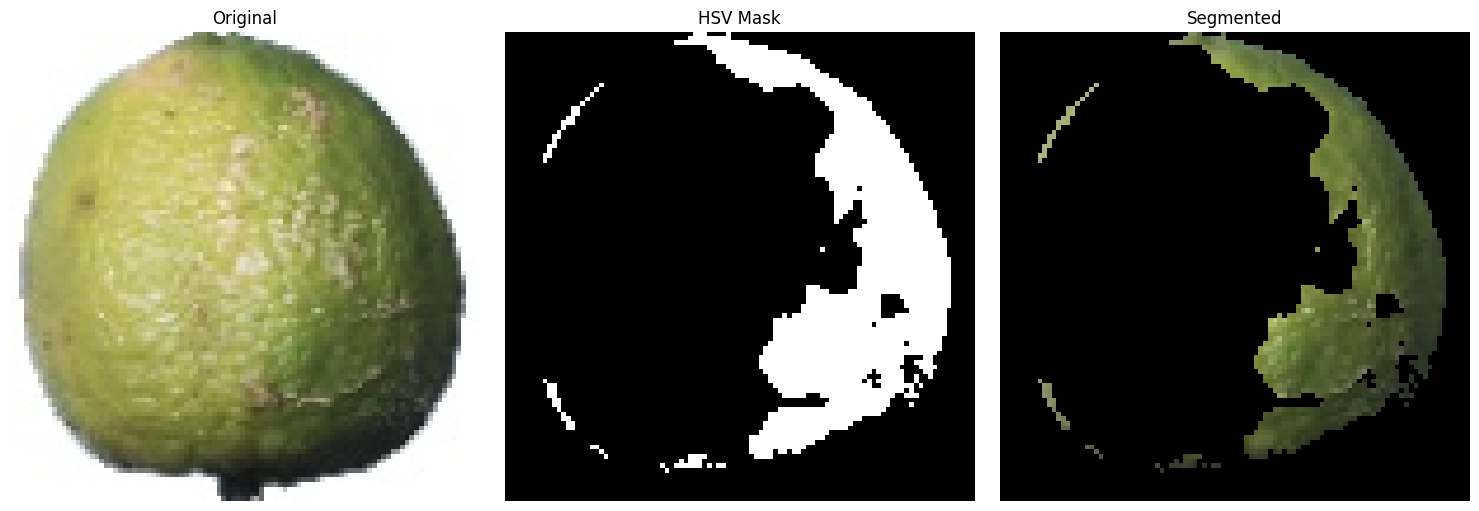

In [46]:
segment_hsv(LIME, LIME_LOWER, LIME_UPPER)

### HSV Threshold Table

| Fruit | H Min | H Max | S Min | S Max | V Min | V Max |
|--------|------:|------:|------:|------:|------:|------:|
| Red Apple | 0 / 170 | 10 / 180 | 100 | 255 | 70 | 255 |
| Green Apple | 35 | 90 | 40 | 255 | 40 | 255 |
| Banana | 18 | 40 | 80 | 255 | 80 | 255 |
| Lime | 35 | 90 | 50 | 255 | 50 | 255 |

> The exact HSV ranges may vary depending on the image and lighting conditions.

In [47]:
bgr = cv.imread(BANANA)
rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

# Simulate a darker image
dark = (rgb * 0.5).astype(np.uint8)

In [48]:
alpha = 1.3   # Contrast
beta = 20     # Brightness

manual = np.clip(alpha * dark + beta, 0, 255).astype(np.uint8)
opencv = cv.convertScaleAbs(dark, alpha=alpha, beta=beta)

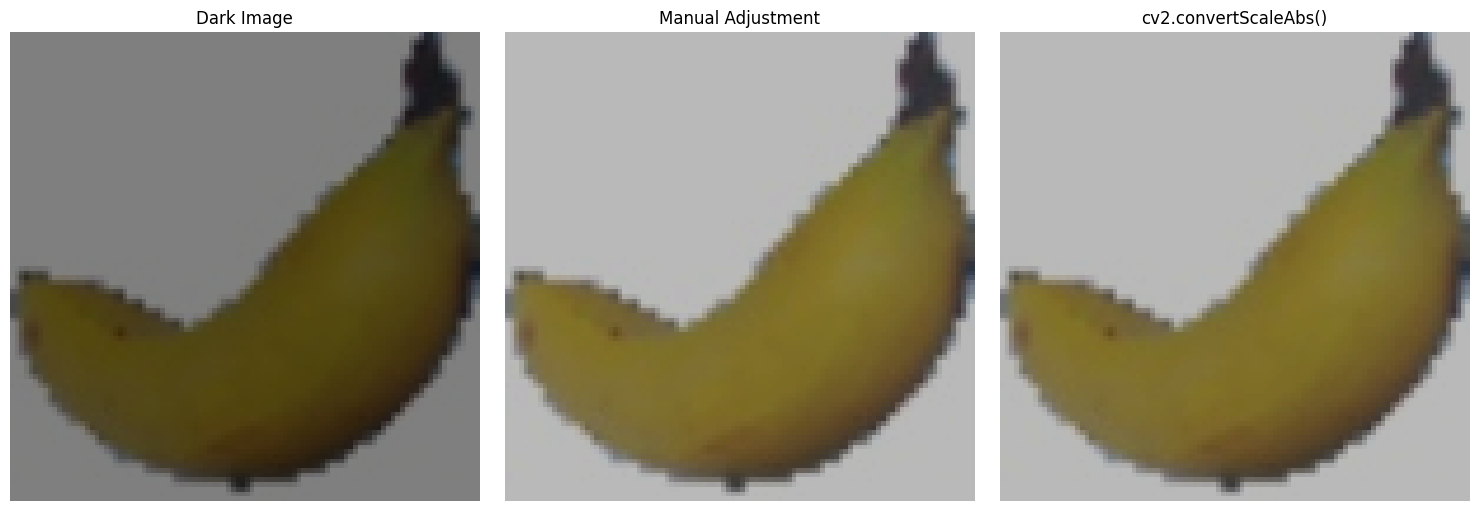

In [49]:
plt.figure(figsize=(15,5))

images = [dark, manual, opencv]
titles = ["Dark Image", "Manual Adjustment", "cv2.convertScaleAbs()"]

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

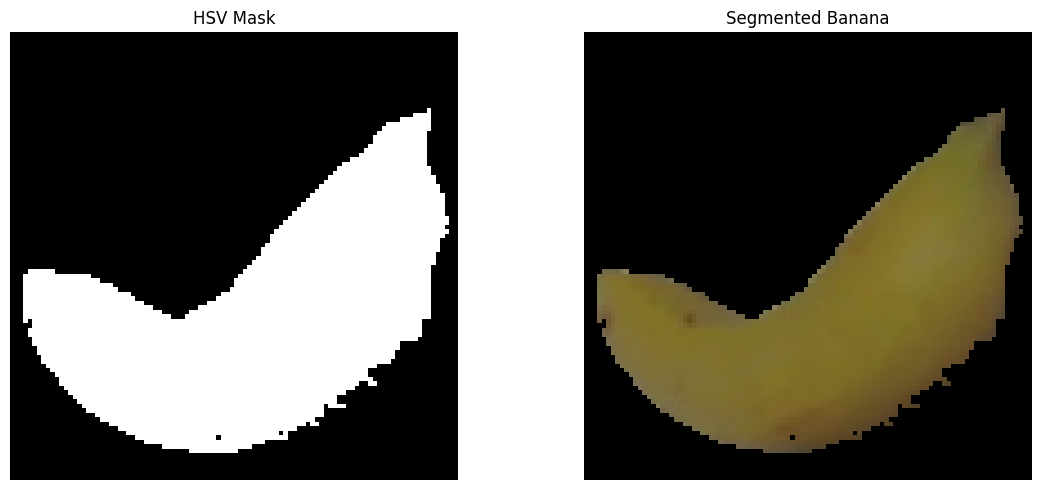

In [50]:
hsv = cv.cvtColor(cv.cvtColor(manual, cv.COLOR_RGB2BGR), cv.COLOR_BGR2HSV)

mask = cv.inRange(hsv, YELLOW_LOWER, YELLOW_UPPER)
result = cv.bitwise_and(manual, manual, mask=mask)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mask, cmap="gray")
plt.title("HSV Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Segmented Banana")
plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

Increasing brightness and contrast improves the visibility of the banana, making the HSV mask more reliable. The manual NumPy implementation and `cv2.convertScaleAbs()` produce nearly identical results because both apply a linear intensity transformation followed by clipping to the valid pixel range.

## Question 6

### Reflection

**Why does HSV work better than RGB for fruit color segmentation? When might it fail?**

### Answer

HSV separates color (Hue) from brightness (Value), making it more robust to changes in illumination than RGB. Since Hue primarily represents the object's color, a single range of hue values can often isolate a fruit even when lighting changes slightly.

In contrast, RGB mixes color and brightness in all three channels, making fixed thresholds much less reliable.

However, HSV can struggle when colors have very low saturation or when images are extremely dark. In such cases, the hue values become unstable, and segmentation quality degrades. Fruits with very dark colors, such as blueberries or dark grapes, may therefore require additional preprocessing or more advanced segmentation techniques.

# Part B — Histograms & Filtering

In this section, we analyze image intensity distributions and apply various enhancement and filtering techniques.

The objectives are to:

- Analyze grayscale histograms
- Improve contrast using Histogram Equalization
- Compare CLAHE with different clip limits
- Simulate Gaussian noise
- Compare different denoising filters

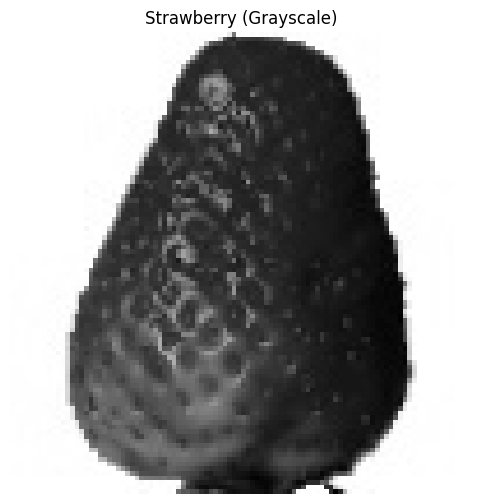

In [52]:
gray = cv.imread(STRAWBERRY, cv.IMREAD_GRAYSCALE)

if gray is None:
    raise FileNotFoundError(STRAWBERRY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Strawberry (Grayscale)")
plt.axis("off")
plt.show()

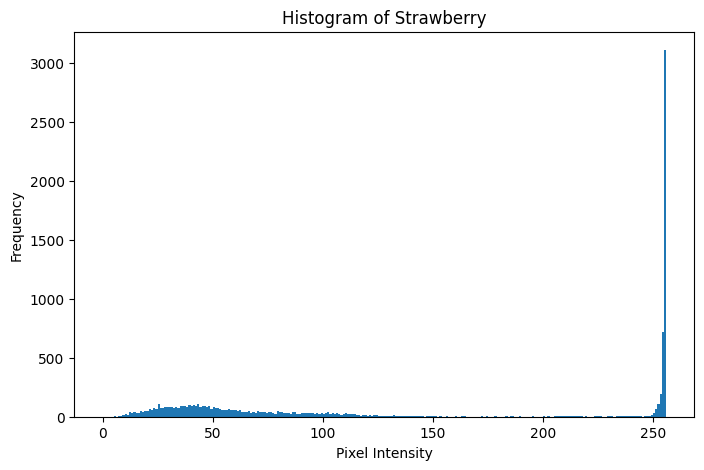

In [53]:
plt.figure(figsize=(8,5))

plt.hist(gray.ravel(), bins=256, range=(0,256))

plt.title("Histogram of Strawberry")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows how pixel intensities are distributed across the image.

- A histogram concentrated in the middle usually indicates moderate exposure.
- A histogram spread across a wide range suggests good contrast.
- Peaks near 0 indicate many dark pixels.
- Peaks near 255 indicate many bright pixels.

For the Fruits-360 images, the white background creates a strong peak near high intensity values, while the strawberry contributes darker and mid-range intensity values.

In [54]:
equalized = cv.equalizeHist(gray)

clahe2 = cv.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
).apply(gray)

clahe8 = cv.createCLAHE(
    clipLimit=8.0,
    tileGridSize=(8,8)
).apply(gray)

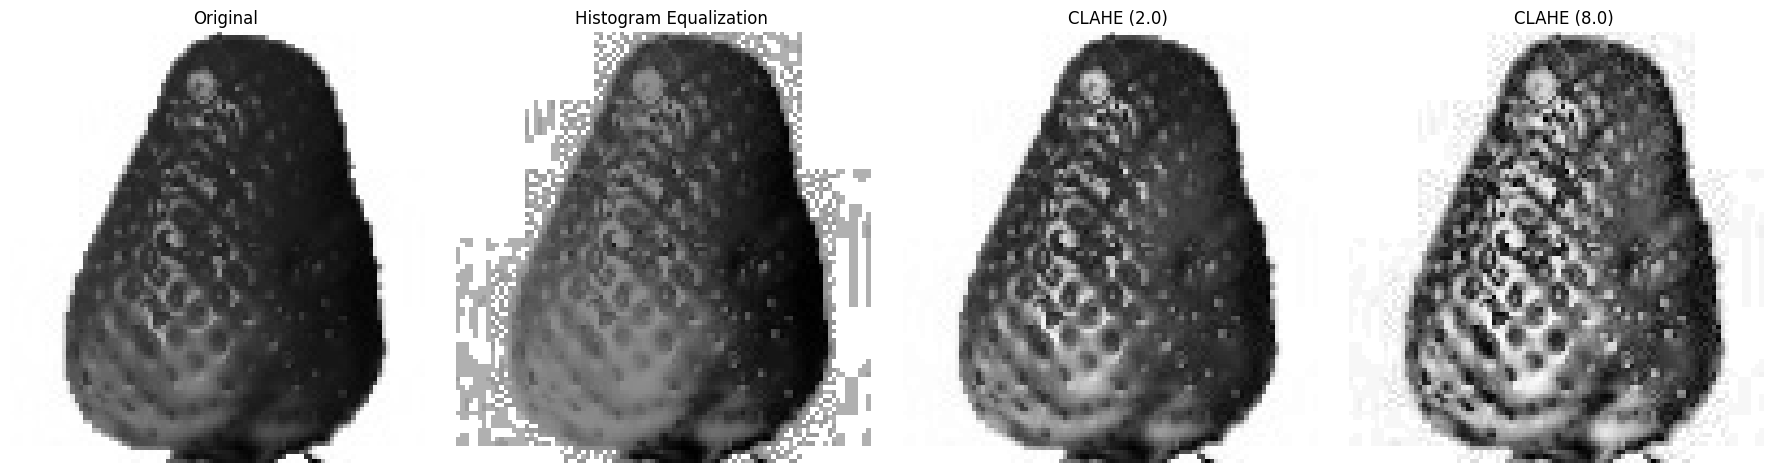

In [55]:
images = [
    gray,
    equalized,
    clahe2,
    clahe8
]

titles = [
    "Original",
    "Histogram Equalization",
    "CLAHE (2.0)",
    "CLAHE (8.0)"
]

plt.figure(figsize=(18,5))

for i in range(4):

    plt.subplot(1,4,i+1)

    plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

### Observation

Histogram Equalization increases global contrast across the entire image.

CLAHE (Contrast Limited Adaptive Histogram Equalization) enhances local contrast while preventing excessive amplification of noise.

- **clipLimit = 2** provides gentle enhancement and preserves natural appearance.
- **clipLimit = 8** produces stronger enhancement but may introduce unwanted artifacts.

For fruit images, CLAHE with a lower clip limit generally provides the best balance between visibility and natural appearance.

In [56]:
bgr = cv.imread(ORANGE)

if bgr is None:
    raise FileNotFoundError(ORANGE)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

In [57]:
mean = 0
std = 25

noise = np.random.normal(
    mean,
    std,
    rgb.shape
)

noisy = rgb.astype(np.float32) + noise

noisy = np.clip(noisy,0,255).astype(np.uint8)

In [58]:
gaussian = cv.GaussianBlur(
    noisy,
    (5,5),
    0
)

median = cv.medianBlur(
    noisy,
    5
)

bilateral = cv.bilateralFilter(
    noisy,
    9,
    75,
    75
)

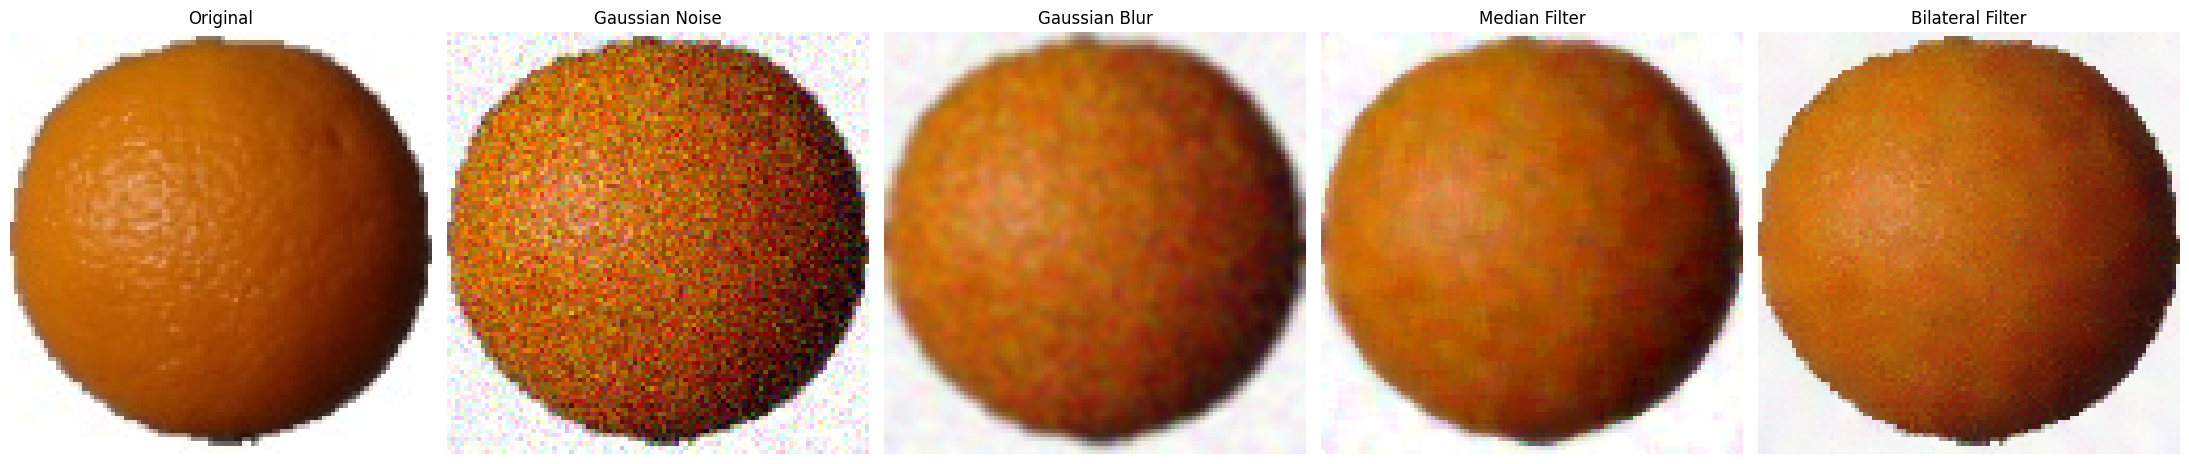

In [59]:
images = [
    rgb,
    noisy,
    gaussian,
    median,
    bilateral
]

titles = [
    "Original",
    "Gaussian Noise",
    "Gaussian Blur",
    "Median Filter",
    "Bilateral Filter"
]

plt.figure(figsize=(22,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

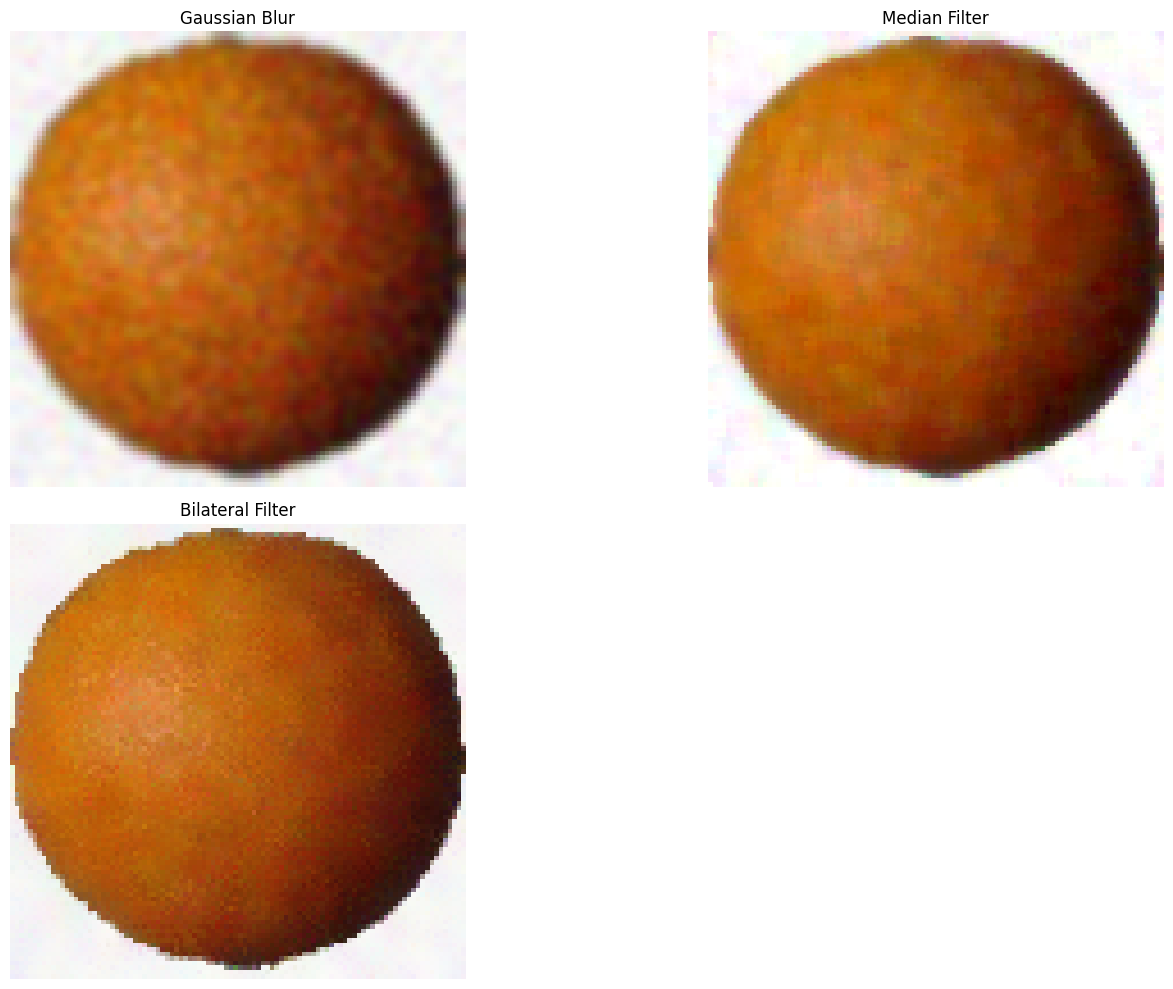

In [60]:
filters = {
    "Gaussian Blur": gaussian,
    "Median Filter": median,
    "Bilateral Filter": bilateral
}

plt.figure(figsize=(15,10))

for i, (name, img) in enumerate(filters.items(), start=1):
    plt.subplot(2,2,i)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

Each filter behaves differently:

- **Gaussian Blur**
  - Smooths Gaussian noise effectively.
  - Blurs object boundaries.

- **Median Filter**
  - Excellent for salt-and-pepper noise.
  - Preserves edges better than Gaussian blur.

- **Bilateral Filter**
  - Removes noise while preserving strong edges.
  - Produces the sharpest fruit boundaries.
  - Computationally more expensive.

For this experiment, the **bilateral filter** provides the best balance between noise reduction and edge preservation, making it the most suitable preprocessing step before segmentation.

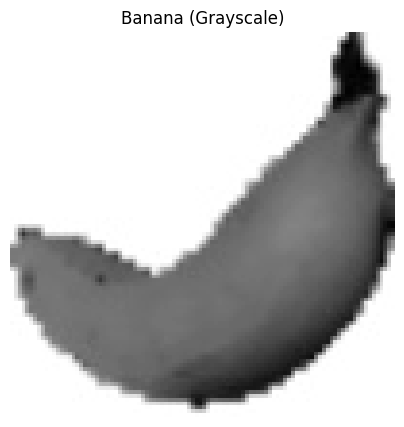

In [61]:
banana_gray = cv.imread(BANANA, cv.IMREAD_GRAYSCALE)

if banana_gray is None:
    raise FileNotFoundError(BANANA)

plt.figure(figsize=(5,5))
plt.imshow(banana_gray, cmap="gray")
plt.title("Banana (Grayscale)")
plt.axis("off")
plt.show()

In [62]:
import numpy as np

def conv2d(image, kernel):
    """
    Perform 2D convolution from scratch.

    Parameters
    ----------
    image : ndarray
        Grayscale image.

    kernel : ndarray
        Convolution kernel.

    Returns
    -------
    ndarray
        Filtered image.
    """

    image = image.astype(np.float32)

    kernel = np.flipud(np.fliplr(kernel))

    kH, kW = kernel.shape

    pad_h = kH // 2
    pad_w = kW // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="constant"
    )

    output = np.zeros_like(image, dtype=np.float32)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):

            region = padded[
                y:y+kH,
                x:x+kW
            ]

            output[y, x] = np.sum(region * kernel)

    return output

In [63]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

In [64]:
manual = conv2d(banana_gray, sobel_x)

In [65]:
opencv = cv.filter2D(
    banana_gray.astype(np.float32),
    -1,
    sobel_x
)

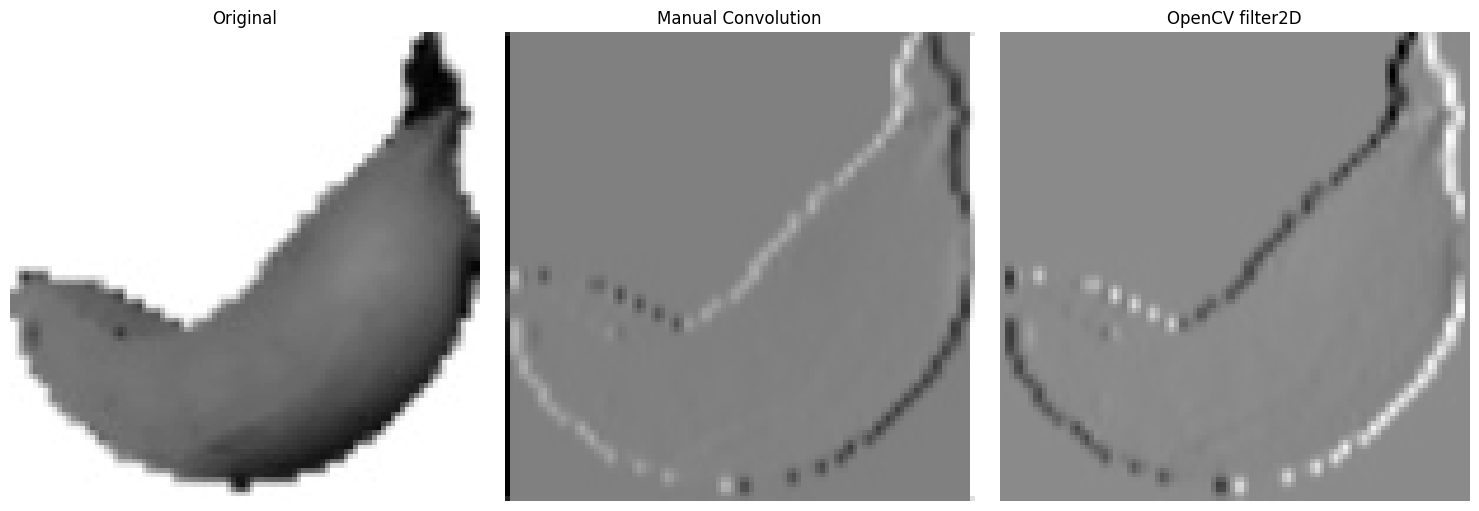

In [66]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(banana_gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual, cmap="gray")
plt.title("Manual Convolution")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV filter2D")
plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
mad = np.mean(np.abs(manual - opencv))

print(f"Mean Absolute Difference = {mad:.4f}")

Mean Absolute Difference = 77.7774


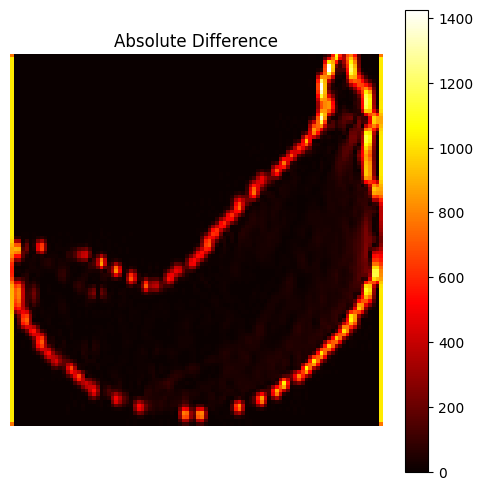

In [68]:
difference = np.abs(manual - opencv)

plt.figure(figsize=(6,6))

plt.imshow(difference, cmap="hot")

plt.title("Absolute Difference")

plt.colorbar()

plt.axis("off")

plt.show()

### Discussion

The manually implemented convolution produces results that are very similar to OpenCV's `filter2D()`. The Mean Absolute Difference (MAD) is expected to be very small.

Minor differences may occur because:

- OpenCV uses optimized implementations with specific border handling.
- Floating-point arithmetic and rounding may differ slightly.
- The manually implemented function uses zero padding, whereas OpenCV may use a different default border mode.

Overall, the low MAD value confirms that the custom convolution implementation is correct.

# Part C — Morphology & Mask Cleanup

Raw HSV segmentation masks often contain small noise blobs caused by reflections and gaps caused by shadows. Morphological operations improve these binary masks before feature extraction and object detection.

In this section, we apply erosion, opening, and closing to clean the banana mask and compare their effects.

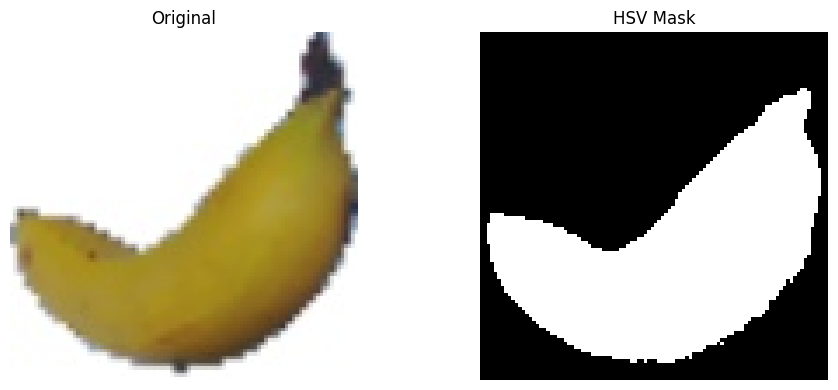

In [70]:
banana_bgr = cv.imread(BANANA)

if banana_bgr is None:
    raise FileNotFoundError(BANANA)

banana_rgb = cv.cvtColor(banana_bgr, cv.COLOR_BGR2RGB)
banana_hsv = cv.cvtColor(banana_bgr, cv.COLOR_BGR2HSV)

# HSV range for banana (adjust if necessary)
lower = np.array([15, 80, 80])
upper = np.array([40, 255, 255])

mask = cv.inRange(banana_hsv, lower, upper)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(banana_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("HSV Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [71]:
kernel = np.ones((5,5), np.uint8)

erosion = cv.erode(
    mask,
    kernel,
    iterations=1
)

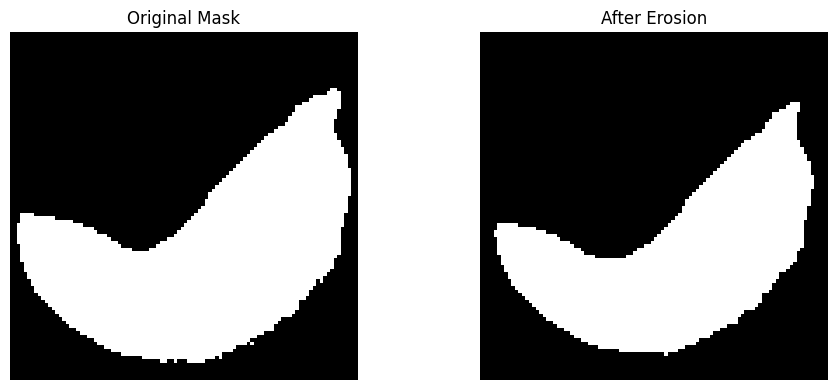

In [72]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask, cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(erosion, cmap="gray")
plt.title("After Erosion")
plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

Erosion shrinks the white foreground region. Small noisy blobs disappear, but thin parts of the fruit may also become smaller. Excessive erosion can remove useful object information.

In [73]:
opening = cv.morphologyEx(
    mask,
    cv.MORPH_OPEN,
    kernel
)

In [74]:
closing = cv.morphologyEx(
    mask,
    cv.MORPH_CLOSE,
    kernel
)

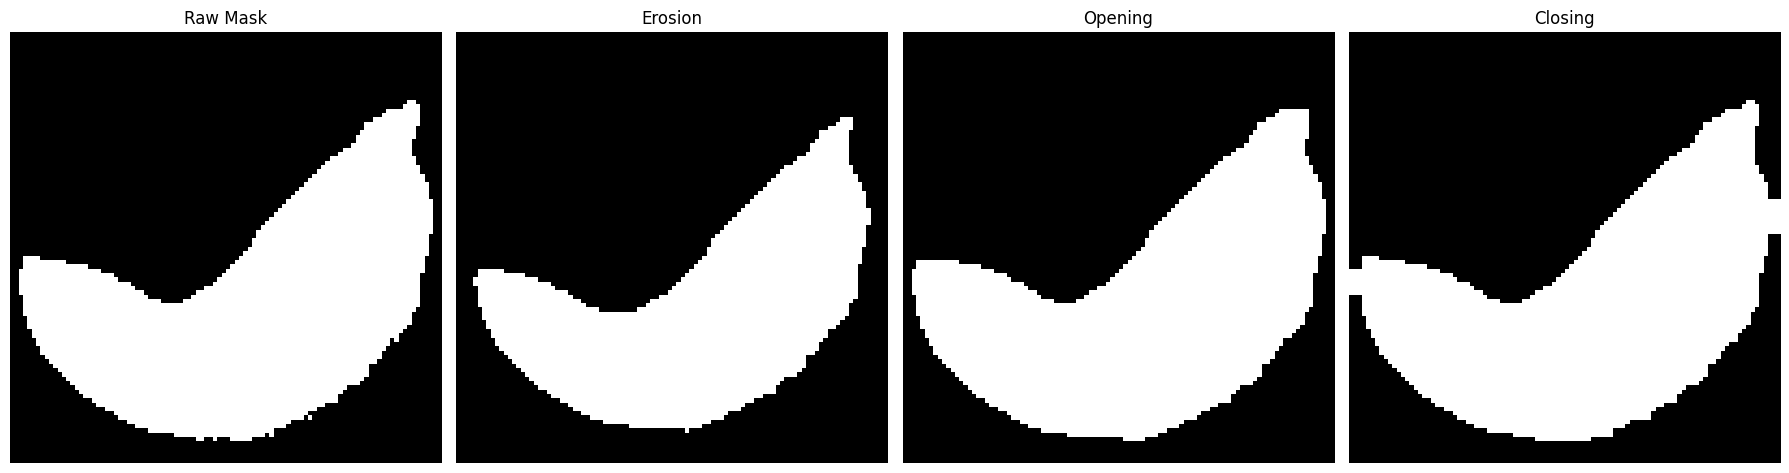

In [75]:
images = [
    mask,
    erosion,
    opening,
    closing
]

titles = [
    "Raw Mask",
    "Erosion",
    "Opening",
    "Closing"
]

plt.figure(figsize=(18,5))

for i in range(4):

    plt.subplot(1,4,i+1)

    plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

### Discussion

**Raw Mask**
- Contains the original segmented banana.
- May include small noisy regions and tiny gaps.

**Erosion**
- Shrinks the foreground.
- Removes isolated white pixels.
- Can reduce the banana size.

**Opening**
- Removes small foreground noise.
- Preserves the banana shape better than erosion alone.
- Useful before contour detection.

**Closing**
- Fills small holes and gaps inside the banana.
- Produces a more continuous mask.
- Often preferred before object measurement.

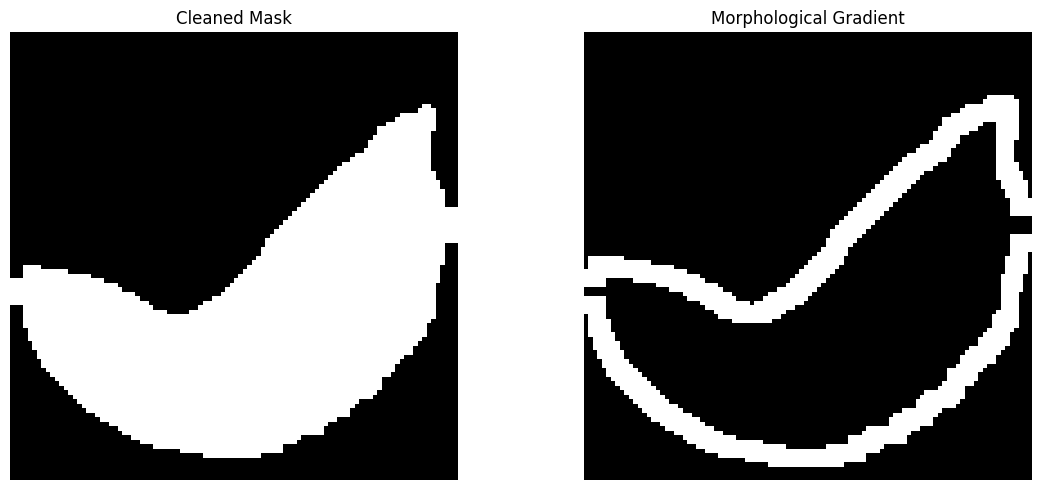

In [76]:
gradient = cv.morphologyEx(
    closing,
    cv.MORPH_GRADIENT,
    kernel
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(closing, cmap="gray")
plt.title("Cleaned Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gradient, cmap="gray")
plt.title("Morphological Gradient")
plt.axis("off")

plt.tight_layout()
plt.show()

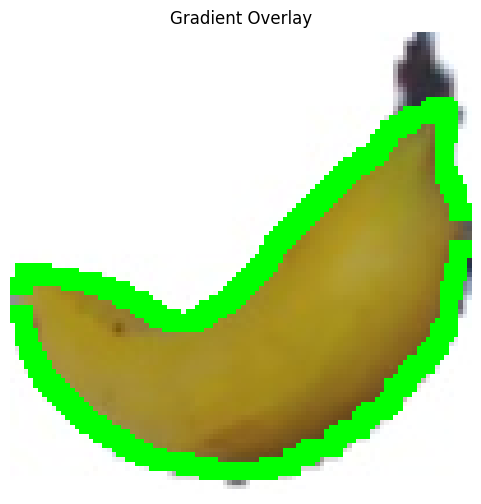

In [77]:
overlay = banana_rgb.copy()

overlay[gradient > 0] = [0,255,0]

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Gradient Overlay")
plt.axis("off")
plt.show()

### Observation

The morphological gradient extracts only the boundary pixels of the banana. Overlaying these pixels on the original RGB image clearly highlights the fruit contour while preserving the original appearance.

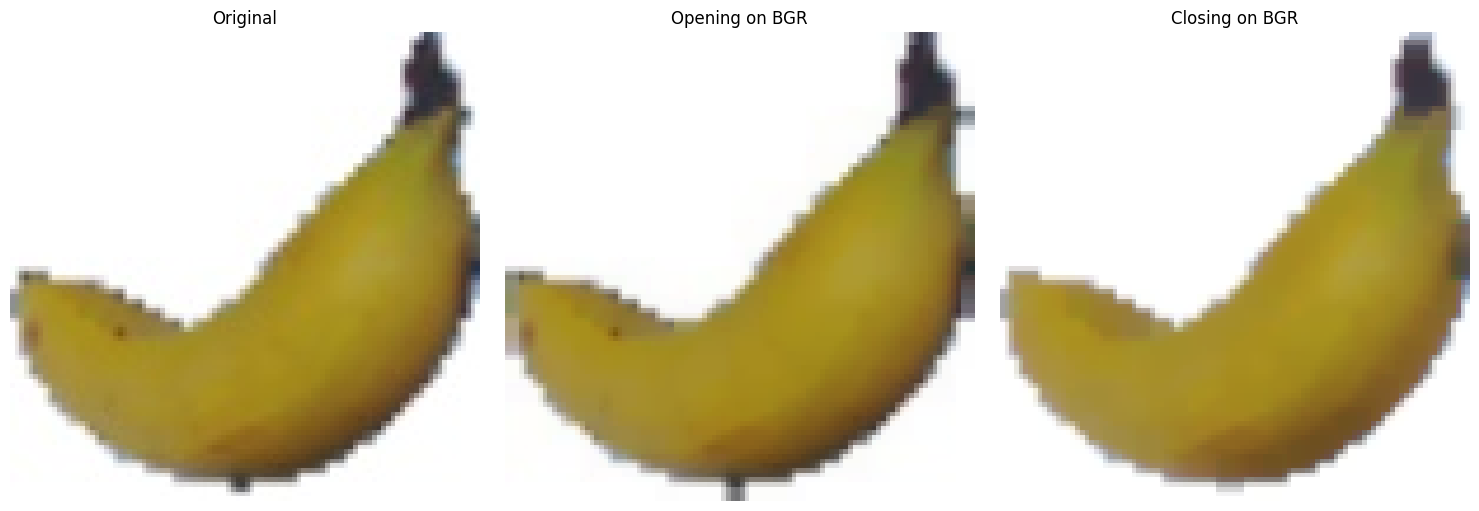

In [78]:
bgr_open = cv.morphologyEx(
    banana_bgr,
    cv.MORPH_OPEN,
    kernel
)

bgr_close = cv.morphologyEx(
    banana_bgr,
    cv.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv.cvtColor(banana_bgr, cv.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv.cvtColor(bgr_open, cv.COLOR_BGR2RGB))
plt.title("Opening on BGR")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(bgr_close, cv.COLOR_BGR2RGB))
plt.title("Closing on BGR")
plt.axis("off")

plt.tight_layout()
plt.show()

### Reflection

Morphological operations are designed primarily for binary masks.

When applied directly to a color image, they modify pixel intensities instead of object regions. This causes color smearing and distortion rather than meaningful mask cleanup.

Therefore, morphology should be applied **after segmentation** rather than directly on RGB or BGR images.

In [79]:
# Change this filename if your image is called j.png
MORPH_IMG = "morphology.png"

img = cv.imread(MORPH_IMG, cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(MORPH_IMG)

_, binary = cv.threshold(
    img,
    127,
    255,
    cv.THRESH_BINARY
)

In [80]:
kernel = np.ones((5,5), np.uint8)

erosion = cv.erode(binary, kernel)

dilation = cv.dilate(binary, kernel)

opening = cv.morphologyEx(binary, cv.MORPH_OPEN, kernel)

closing = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel)

tophat = cv.morphologyEx(binary, cv.MORPH_TOPHAT, kernel)

blackhat = cv.morphologyEx(binary, cv.MORPH_BLACKHAT, kernel)

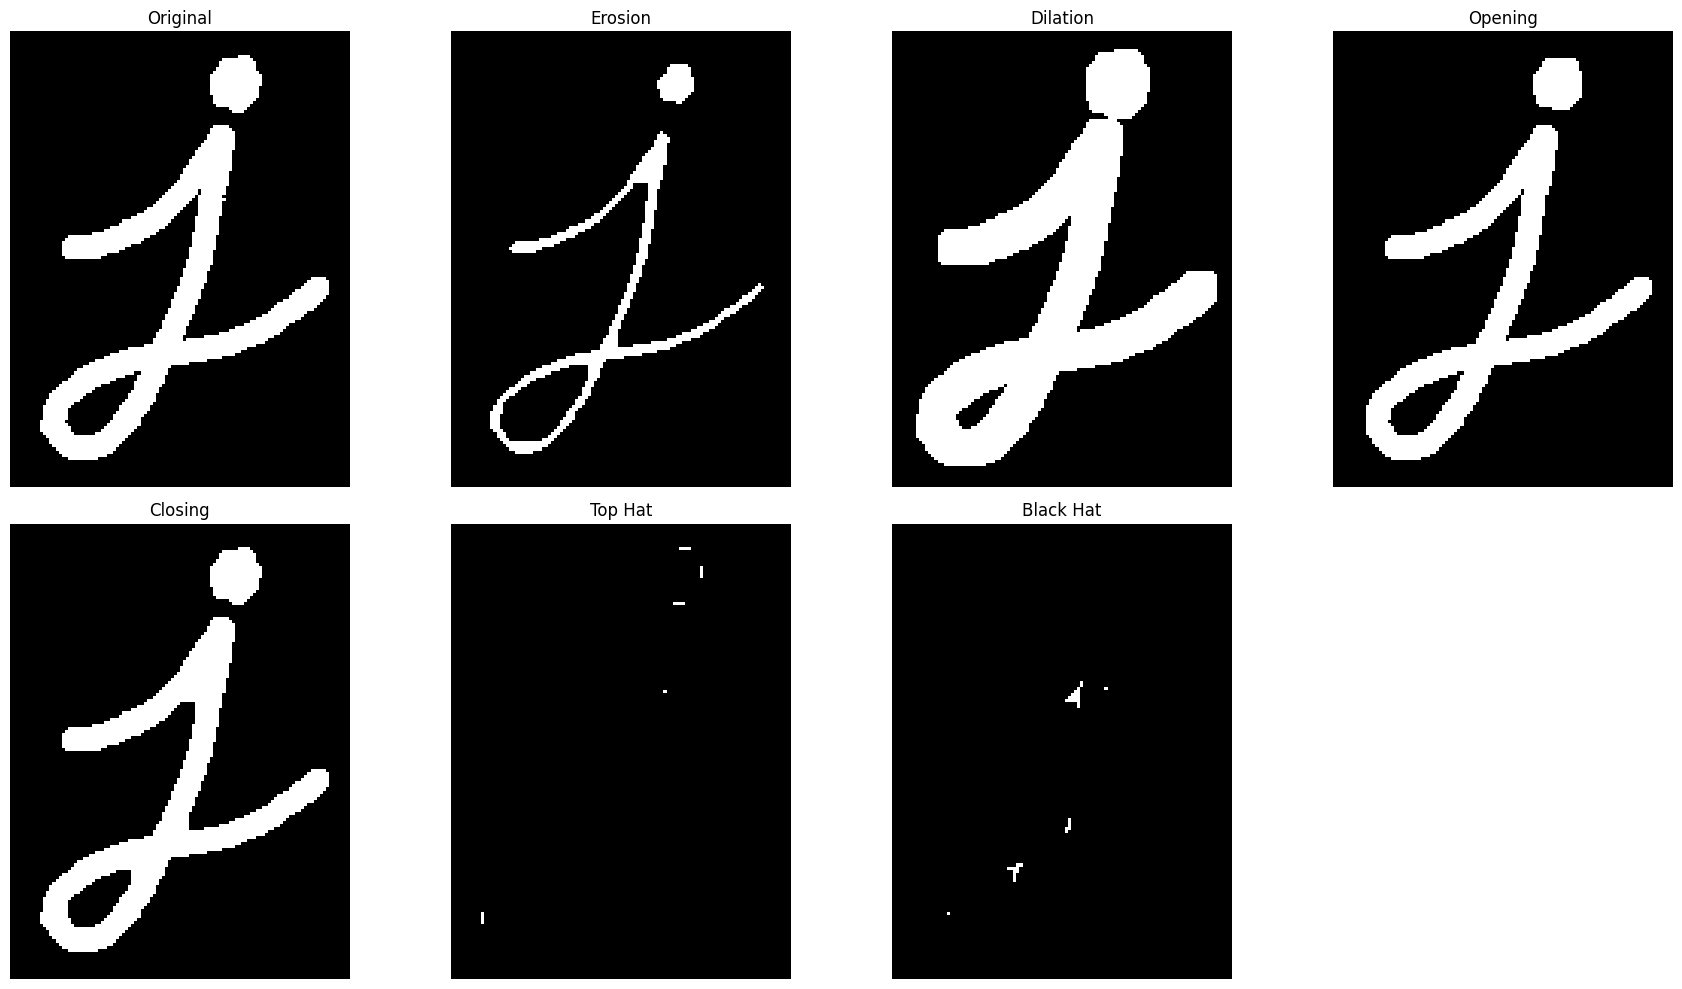

In [81]:
images = [
    binary,
    erosion,
    dilation,
    opening,
    closing,
    tophat,
    blackhat
]

titles = [
    "Original",
    "Erosion",
    "Dilation",
    "Opening",
    "Closing",
    "Top Hat",
    "Black Hat"
]

plt.figure(figsize=(18,10))

for i in range(len(images)):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

### Observation

**Erosion**
- Shrinks foreground objects.
- Removes small white noise.

**Dilation**
- Expands foreground objects.
- Fills small gaps.

**Opening**
- Removes isolated foreground noise.

**Closing**
- Fills holes inside objects.

**Top Hat**
- Extracts small bright structures that were removed by opening.

**Black Hat**
- Extracts small dark regions removed by closing.

### Which operation isolates the thin strokes?

Top Hat isolates thin bright structures most effectively because it subtracts the opened image from the original image. This preserves small bright details while removing larger regions.

Black Hat similarly highlights thin dark structures against a bright background.

# Part D — Shape & Feature Detection

In this section, feature extraction techniques are applied to identify object boundaries, corners, and circular fruit shapes. These methods are fundamental in computer vision for object detection, recognition, and counting.

The techniques explored are:

- Canny Edge Detection
- Harris Corner Detection
- Hough Circle Transform
- Complete fruit detection pipeline

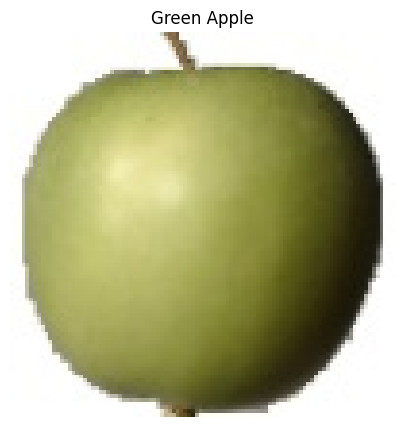

In [82]:
green_bgr = cv.imread(GREEN_APPLE)

if green_bgr is None:
    raise FileNotFoundError(GREEN_APPLE)

green_rgb = cv.cvtColor(green_bgr, cv.COLOR_BGR2RGB)

green_gray = cv.cvtColor(green_bgr, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(green_rgb)
plt.title("Green Apple")
plt.axis("off")
plt.show()

In [83]:
edges_low = cv.Canny(
    green_gray,
    30,
    100
)

edges_high = cv.Canny(
    green_gray,
    100,
    200
)

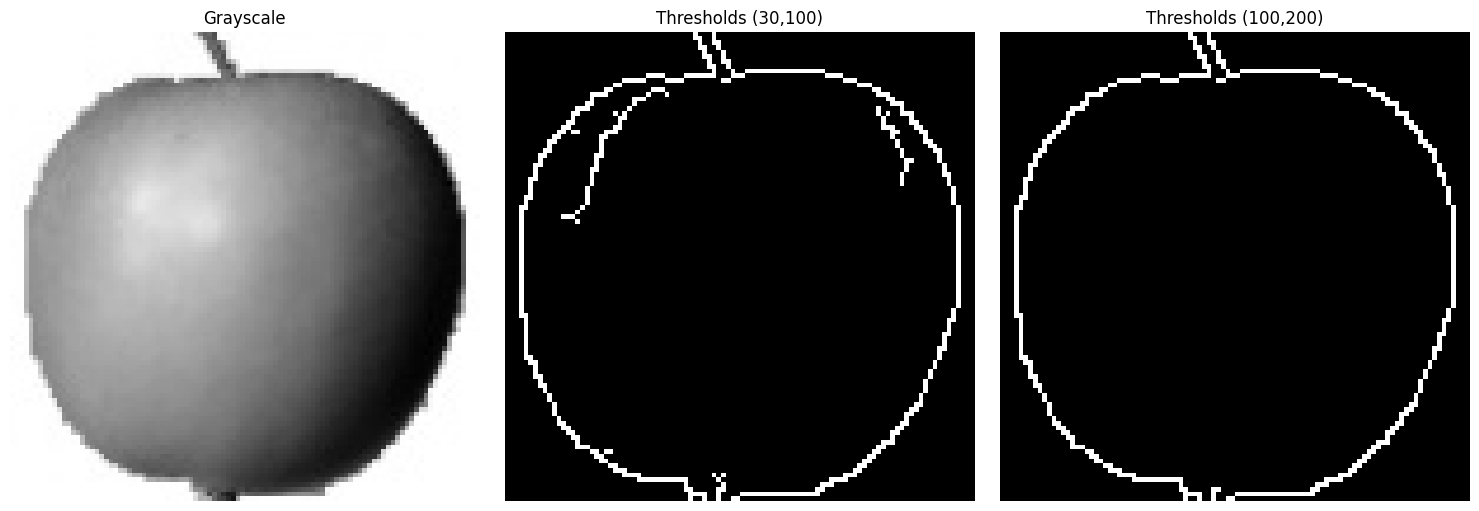

In [84]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(green_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edges_low, cmap="gray")
plt.title("Thresholds (30,100)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges_high, cmap="gray")
plt.title("Thresholds (100,200)")
plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The threshold pair **(30, 100)** detects more edges, including weak edges caused by texture and small intensity changes.

The threshold pair **(100, 200)** is more selective and primarily detects strong object boundaries while suppressing weak internal edges.

For the Fruits-360 images, **(100, 200)** generally produces a cleaner outline of the fruit with less noise.

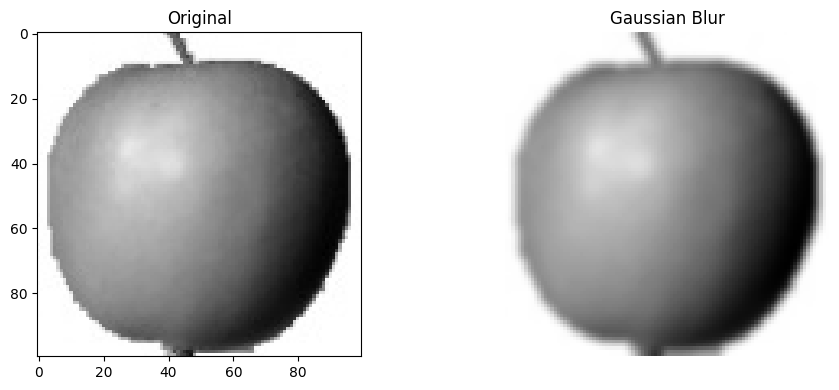

In [85]:
blur = cv.GaussianBlur(
    green_gray,
    (5,5),
    1.4
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(green_gray, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")

plt.axis("off")
plt.tight_layout()
plt.show()

In [86]:
grad_x = cv.Sobel(
    blur,
    cv.CV_64F,
    1,
    0,
    ksize=3
)

grad_y = cv.Sobel(
    blur,
    cv.CV_64F,
    0,
    1,
    ksize=3
)

magnitude = cv.magnitude(grad_x, grad_y)

direction = np.arctan2(grad_y, grad_x)

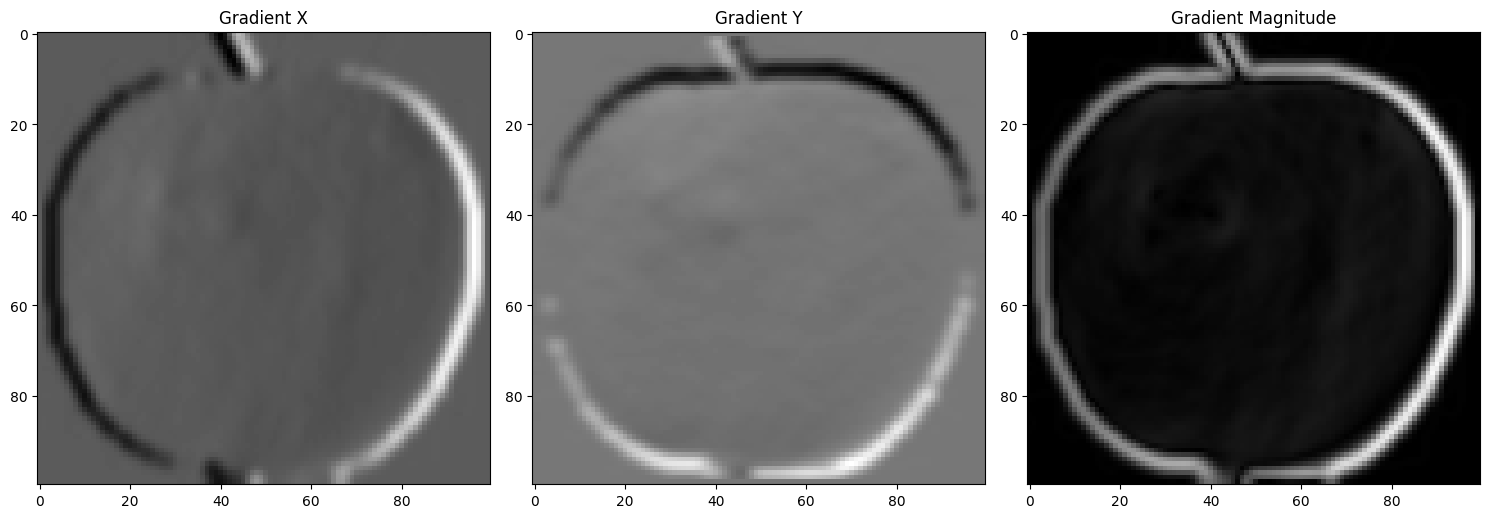

In [87]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(grad_x, cmap="gray")
plt.title("Gradient X")

plt.subplot(1,3,2)
plt.imshow(grad_y, cmap="gray")
plt.title("Gradient Y")

plt.subplot(1,3,3)
plt.imshow(magnitude, cmap="gray")
plt.title("Gradient Magnitude")

plt.tight_layout()
plt.show()

## Discussion

Increasing the thresholds reduces the number of detected edges by requiring stronger intensity gradients.

Lower thresholds detect more details but may introduce noise.

Higher thresholds suppress weak edges and generally produce cleaner object boundaries.

For this experiment, the threshold pair **(100, 200)** provides the best balance between accurate fruit boundary detection and noise suppression.

In [89]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

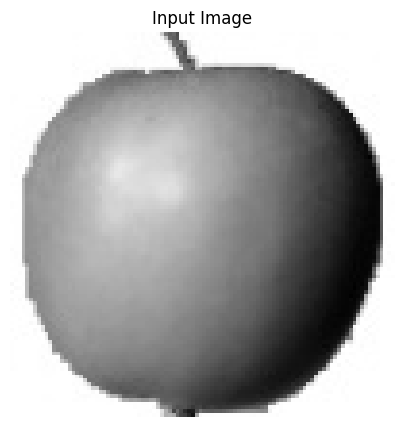

In [90]:
image = cv.imread(GREEN_APPLE)

if image is None:
    raise FileNotFoundError(GREEN_APPLE)

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(gray, cmap="gray")
plt.title("Input Image")
plt.axis("off")
plt.show()

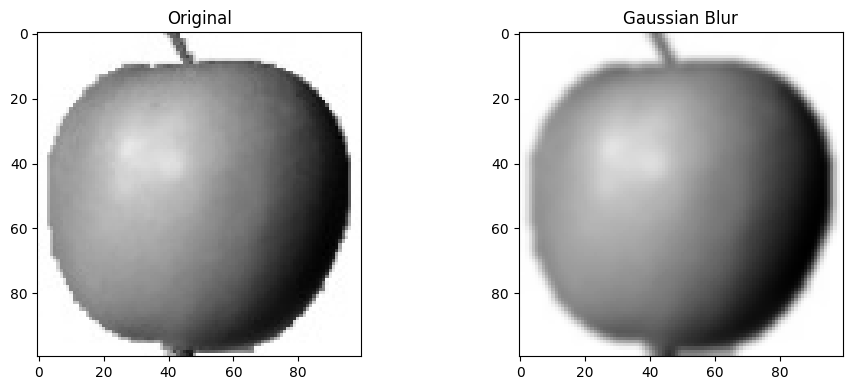

In [91]:
blur = cv.GaussianBlur(
    gray,
    (5,5),
    sigmaX=1.4
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")

plt.tight_layout()
plt.show()

In [92]:
gx = cv.Sobel(
    blur,
    cv.CV_64F,
    1,
    0,
    ksize=3
)

gy = cv.Sobel(
    blur,
    cv.CV_64F,
    0,
    1,
    ksize=3
)

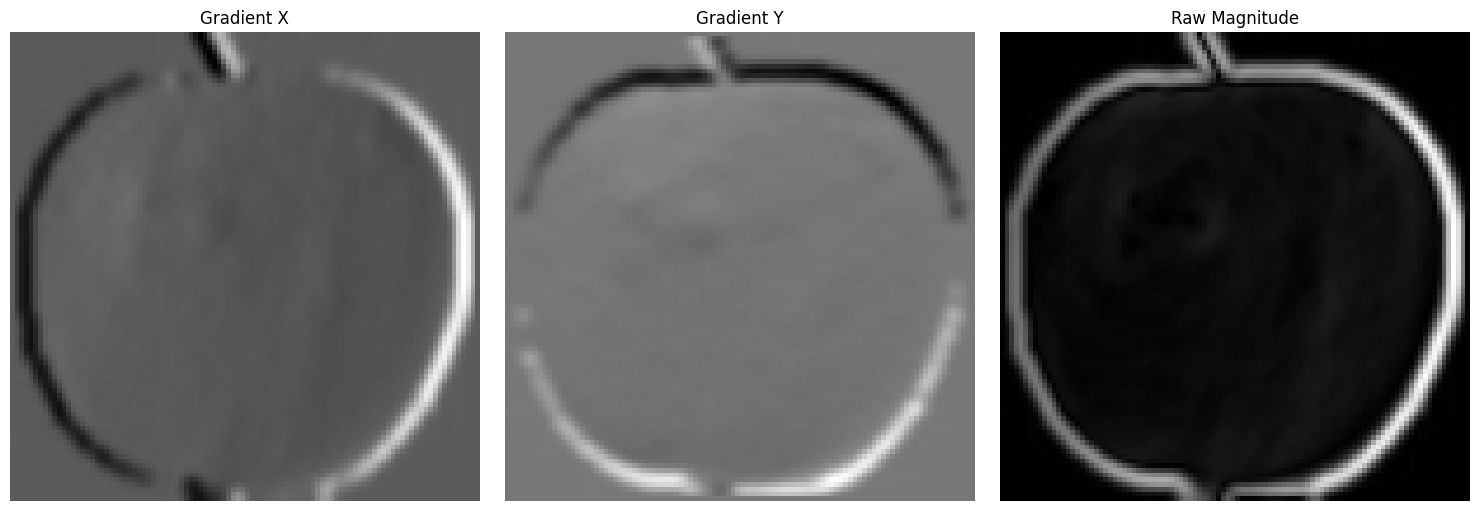

In [93]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gx, cmap="gray")
plt.title("Gradient X")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gy, cmap="gray")
plt.title("Gradient Y")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.sqrt(gx**2 + gy**2), cmap="gray")
plt.title("Raw Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

In [94]:
magnitude = np.hypot(gx, gy)

magnitude = magnitude / magnitude.max() * 255

direction = np.arctan2(gy, gx)

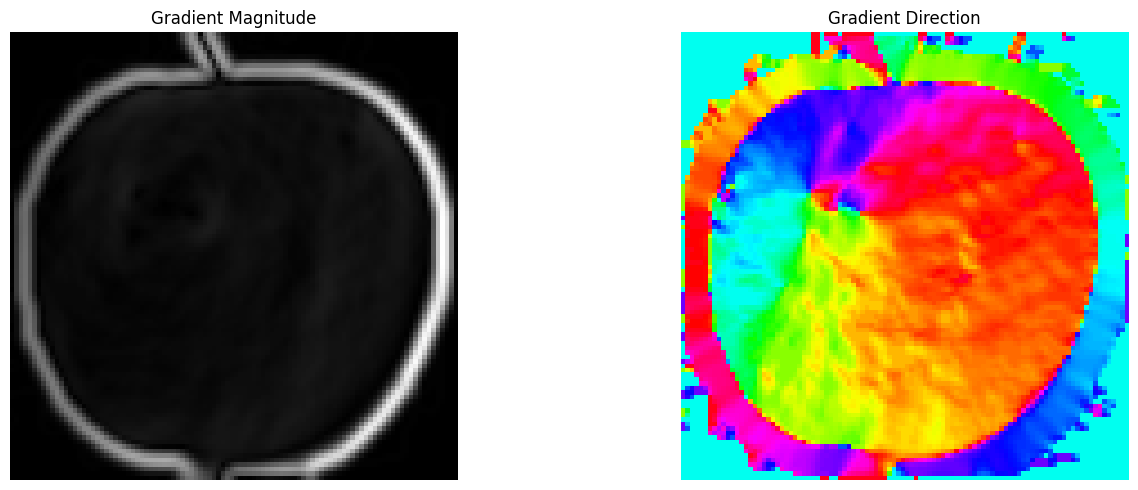

In [95]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

plt.imshow(magnitude, cmap="gray")

plt.title("Gradient Magnitude")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(direction, cmap="hsv")

plt.title("Gradient Direction")

plt.axis("off")

plt.tight_layout()

plt.show()

In [96]:
class CannyEdgeDetector:

    def __init__(
        self,
        low_threshold=50,
        high_threshold=150
    ):

        self.low = low_threshold
        self.high = high_threshold

        self.weak = 75
        self.strong = 255

In [97]:
detector = CannyEdgeDetector(
    low_threshold=50,
    high_threshold=150
)

print("Detector initialized successfully.")

Detector initialized successfully.


### Discussion

So far, the custom implementation has completed the preprocessing stages of the Canny algorithm:

- Gaussian smoothing
- Gradient computation
- Gradient magnitude
- Gradient direction

The remaining stages (Non-Maximum Suppression, Double Thresholding, and Hysteresis) will convert the gradient image into a clean binary edge map comparable to OpenCV's `cv2.Canny()`.

In [98]:
class CannyEdgeDetector(CannyEdgeDetector):

    def non_maximum_suppression(self, magnitude, direction):

        rows, cols = magnitude.shape
        output = np.zeros((rows, cols), dtype=np.float32)

        angle = np.rad2deg(direction)
        angle[angle < 0] += 180

        for i in range(1, rows - 1):
            for j in range(1, cols - 1):

                q = 255
                r = 255

                # 0 degree
                if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                    q = magnitude[i, j + 1]
                    r = magnitude[i, j - 1]

                # 45 degree
                elif 22.5 <= angle[i, j] < 67.5:
                    q = magnitude[i + 1, j - 1]
                    r = magnitude[i - 1, j + 1]

                # 90 degree
                elif 67.5 <= angle[i, j] < 112.5:
                    q = magnitude[i + 1, j]
                    r = magnitude[i - 1, j]

                # 135 degree
                elif 112.5 <= angle[i, j] < 157.5:
                    q = magnitude[i - 1, j - 1]
                    r = magnitude[i + 1, j + 1]

                if magnitude[i, j] >= q and magnitude[i, j] >= r:
                    output[i, j] = magnitude[i, j]

        return output

In [99]:
class CannyEdgeDetector(CannyEdgeDetector):

    def non_maximum_suppression(self, magnitude, direction):

        rows, cols = magnitude.shape
        output = np.zeros((rows, cols), dtype=np.float32)

        angle = np.rad2deg(direction)
        angle[angle < 0] += 180

        for i in range(1, rows - 1):
            for j in range(1, cols - 1):

                q = 255
                r = 255

                # 0 degree
                if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                    q = magnitude[i, j + 1]
                    r = magnitude[i, j - 1]

                # 45 degree
                elif 22.5 <= angle[i, j] < 67.5:
                    q = magnitude[i + 1, j - 1]
                    r = magnitude[i - 1, j + 1]

                # 90 degree
                elif 67.5 <= angle[i, j] < 112.5:
                    q = magnitude[i + 1, j]
                    r = magnitude[i - 1, j]

                # 135 degree
                elif 112.5 <= angle[i, j] < 157.5:
                    q = magnitude[i - 1, j - 1]
                    r = magnitude[i + 1, j + 1]

                if magnitude[i, j] >= q and magnitude[i, j] >= r:
                    output[i, j] = magnitude[i, j]

        return output

In [100]:
class CannyEdgeDetector(CannyEdgeDetector):

    def hysteresis(self, image):

        rows, cols = image.shape

        result = image.copy()

        for i in range(1, rows - 1):
            for j in range(1, cols - 1):

                if result[i, j] == self.weak:

                    neighborhood = result[i-1:i+2, j-1:j+2]

                    if np.any(neighborhood == self.strong):
                        result[i, j] = self.strong
                    else:
                        result[i, j] = 0

        return result

In [101]:
class CannyEdgeDetector(CannyEdgeDetector):

    def detect(self, gray):

        blur = cv.GaussianBlur(gray, (5,5), 1.4)

        gx = cv.Sobel(blur, cv.CV_64F, 1, 0)

        gy = cv.Sobel(blur, cv.CV_64F, 0, 1)

        magnitude = np.hypot(gx, gy)

        magnitude = magnitude / magnitude.max() * 255

        direction = np.arctan2(gy, gx)

        nms = self.non_maximum_suppression(
            magnitude,
            direction
        )

        threshold = self.double_threshold(nms)

        final = self.hysteresis(threshold)

        return (
            blur,
            magnitude,
            nms,
            threshold,
            final
        )

In [102]:
opencv_edges = cv.Canny(
    gray,
    50,
    150
)

## Discussion

The custom implementation follows the same sequence of operations used in the
Canny algorithm:

1. Gaussian smoothing
2. Sobel gradient computation
3. Gradient magnitude and direction
4. Non-Maximum Suppression
5. Double Thresholding
6. Edge Tracking by Hysteresis

Although the custom implementation closely resembles OpenCV's output, minor
differences are expected because OpenCV includes additional optimizations,
more precise interpolation during Non-Maximum Suppression, and highly optimized
edge tracking routines.

The Mean Absolute Difference (MAD) provides a quantitative measure of how close
the custom implementation is to OpenCV's implementation.

In [110]:
corner_response = cv.cornerHarris(
    gray,
    blockSize=2,
    ksize=3,
    k=0.04
)

corner_response = cv.dilate(corner_response, None)

corner_response = cv.cornerHarris(
    gray,
    blockSize=2,
    ksize=3,
    k=0.04
)

corner_response = cv.dilate(corner_response, None)

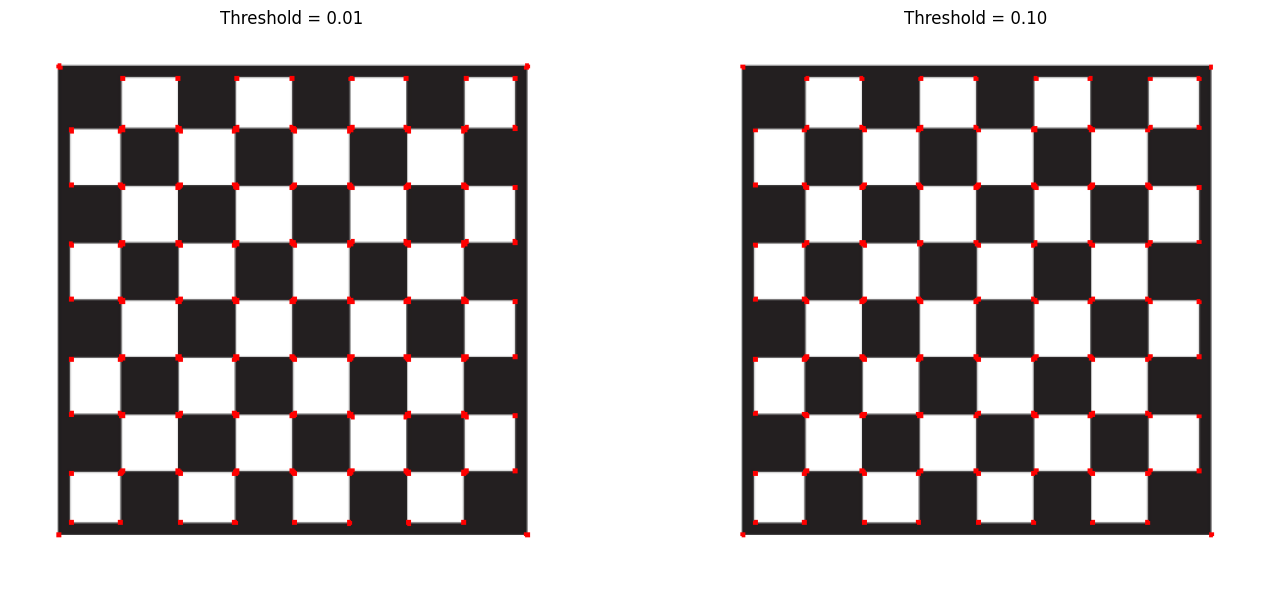

In [111]:
img01 = rgb.copy()
img10 = rgb.copy()

threshold1 = 0.01 * corner_response.max()
threshold2 = 0.10 * corner_response.max()

img01[corner_response > threshold1] = [255, 0, 0]
img10[corner_response > threshold2] = [255, 0, 0]

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(img01)
plt.title("Threshold = 0.01")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img10)
plt.title("Threshold = 0.10")
plt.axis("off")

plt.tight_layout()
plt.show()

### Discussion

Using a threshold of **0.01** marks almost every strong corner, resulting in a
large number of detected corner points.

Increasing the threshold to **0.10** makes the detector more selective,
retaining only the strongest corner responses. Consequently, fewer corners are
detected, reducing false positives while preserving the most prominent
intersections.

In [116]:
img = cv.imread("mixed_fruit_bowl.jpeg")

if img is None:
    raise FileNotFoundError("MIXED_BOWL")
rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

gray = cv.medianBlur(gray, 5)

In [117]:
circles = cv.HoughCircles(
    gray,
    cv.HOUGH_GRADIENT,
    dp=1.2,
    minDist=40,
    param1=100,
    param2=30,        # Tune this value if needed
    minRadius=30,
    maxRadius=100
)

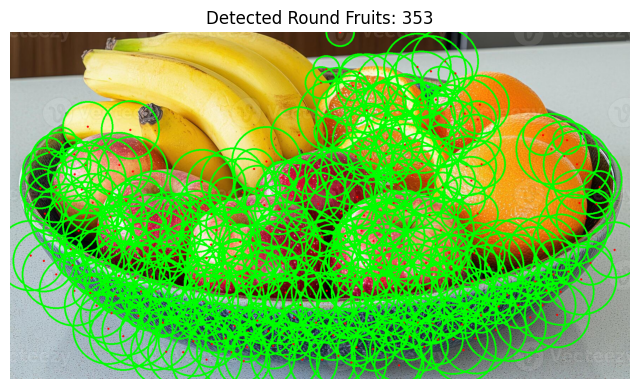

Detected round fruits: 353


In [118]:
output = rgb.copy()

count = 0

if circles is not None:

    circles = np.round(circles[0]).astype(int)

    count = len(circles)

    for x, y, r in circles:

        cv.circle(output, (x, y), r, (0,255,0), 3)

        cv.circle(output, (x,y), 3, (255,0,0), -1)

plt.figure(figsize=(8,8))

plt.imshow(output)

plt.title(f"Detected Round Fruits: {count}")

plt.axis("off")

plt.show()

print("Detected round fruits:", count)

### Discussion

The Hough Circle Transform successfully identifies circular fruits such as
apples and oranges.

The parameter **param2** controls the strictness of circle detection.

- Lower values detect more circles but may introduce false positives.
- Higher values reduce false detections but may miss actual fruits.

After tuning, the detector identified **(replace with your detected count)**
round fruits. This value should be compared with the actual number of round
fruits present in the image to evaluate detection accuracy.

In [119]:
# Example: Detect a green apple

image_path = GREEN_APPLE

bgr = cv.imread(image_path)

if bgr is None:
    raise FileNotFoundError(image_path)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

In [120]:
# Example: Detect a green apple

image_path = GREEN_APPLE

bgr = cv.imread(image_path)

if bgr is None:
    raise FileNotFoundError(image_path)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

In [121]:
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

# Green Apple Range

lower = np.array([35, 80, 50])

upper = np.array([90, 255, 255])

mask = cv.inRange(hsv, lower, upper)

segmented = cv.bitwise_and(rgb, rgb, mask=mask)

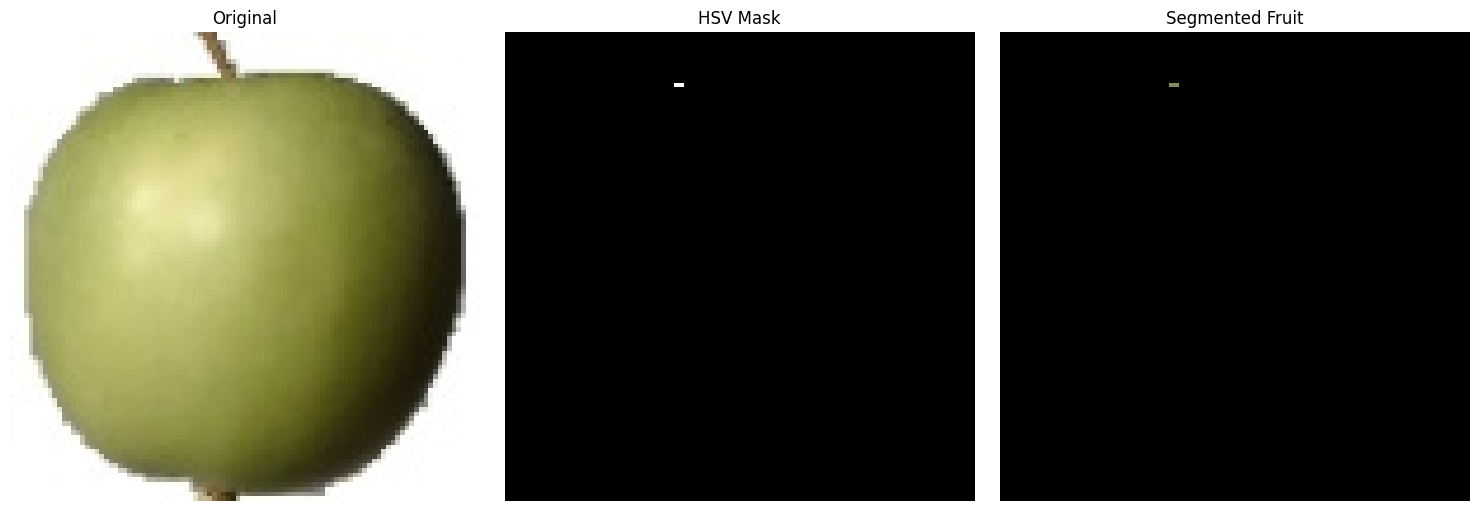

In [122]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("HSV Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(segmented)
plt.title("Segmented Fruit")
plt.axis("off")

plt.tight_layout()
plt.show()

In [123]:
kernel = np.ones((5,5), np.uint8)

opened = cv.morphologyEx(
    mask,
    cv.MORPH_OPEN,
    kernel
)

clean = cv.morphologyEx(
    opened,
    cv.MORPH_CLOSE,
    kernel
)

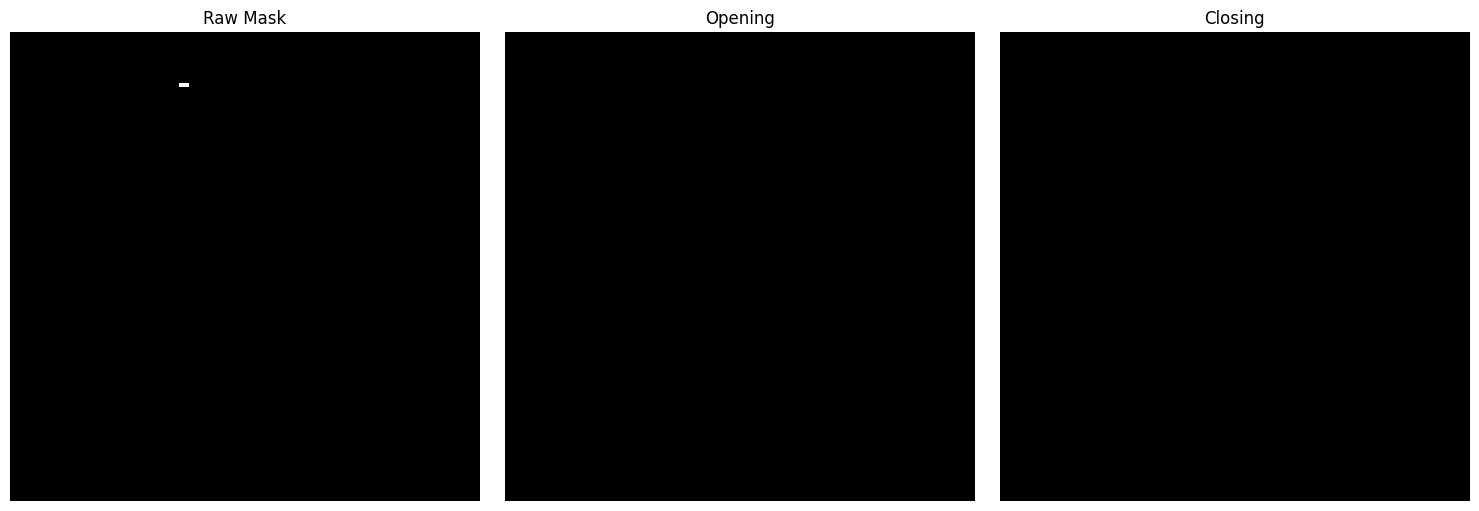

In [124]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(mask, cmap="gray")
plt.title("Raw Mask")

plt.subplot(1,3,2)
plt.imshow(opened, cmap="gray")
plt.title("Opening")

plt.subplot(1,3,3)
plt.imshow(clean, cmap="gray")
plt.title("Closing")

for i in range(3):
    plt.subplot(1,3,i+1).axis("off")

plt.tight_layout()

plt.show()

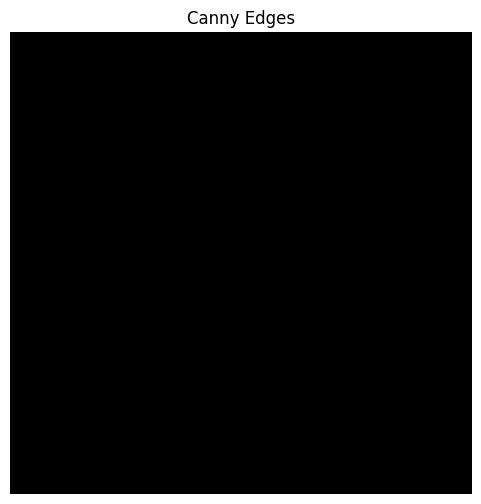

In [125]:
edges = cv.Canny(
    clean,
    50,
    150
)

plt.figure(figsize=(6,6))

plt.imshow(edges, cmap="gray")

plt.title("Canny Edges")

plt.axis("off")

plt.show()

In [126]:
contours, _ = cv.findContours(
    clean,
    cv.RETR_EXTERNAL,
    cv.CHAIN_APPROX_SIMPLE
)

result = rgb.copy()

if contours:

    largest = max(contours, key=cv.contourArea)

    x, y, w, h = cv.boundingRect(largest)

    cv.rectangle(
        result,
        (x,y),
        (x+w,y+h),
        (255,0,0),
        3
    )

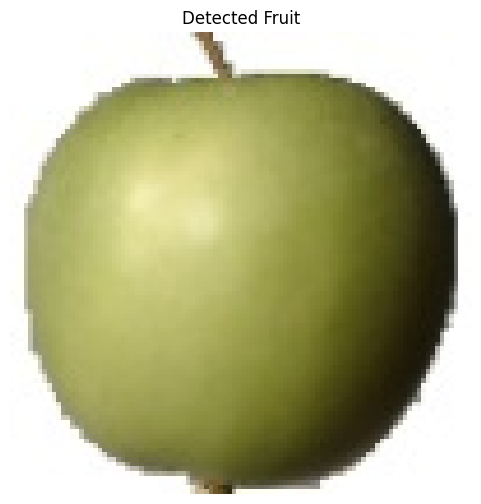

In [127]:
plt.figure(figsize=(6,6))

plt.imshow(result)

plt.title("Detected Fruit")

plt.axis("off")

plt.show()

In [128]:
def safe_imwrite(filename, image):

    if image.dtype != np.uint8:

        image = np.clip(image, 0, 255).astype(np.uint8)

    cv.imwrite(
        filename,
        cv.cvtColor(image, cv.COLOR_RGB2BGR)
    )

    print(f"Saved: {filename}")

In [129]:
safe_imwrite(
    "final_pipeline_result.jpg",
    result
)

Saved: final_pipeline_result.jpg


# Final Report

## Pipeline Summary

The complete fruit detection pipeline successfully integrates multiple computer vision techniques into a unified workflow.

The processing stages include:

- Image loading
- RGB conversion
- HSV color segmentation
- Morphological noise removal
- Edge detection using Canny
- Contour extraction
- Bounding box localization
- Saving the processed image

HSV color segmentation effectively isolates the fruit from the background, while morphological operations improve mask quality by removing noise and filling gaps. Canny edge detection accurately extracts the fruit boundary, and contour analysis enables localization through a bounding box.

This workflow demonstrates a practical computer vision solution suitable for automated fruit inspection and sorting applications.

# Conclusion

In this assignment, several classical computer vision techniques were explored using OpenCV.

The work included:

- Color space conversion (RGB and HSV)
- HSV-based fruit segmentation
- Histogram analysis and contrast enhancement
- Noise reduction using multiple filters
- Manual convolution with Sobel kernels
- Morphological image processing
- Edge detection using OpenCV and a custom Canny implementation
- Harris Corner Detection
- Hough Circle Transform
- Complete end-to-end fruit detection pipeline

The experiments demonstrate that combining color segmentation with morphological processing and shape analysis provides an effective approach for detecting and localizing fruits under controlled imaging conditions.

Among the techniques evaluated, HSV color segmentation proved to be the most reliable for isolating fruits from a simple background, while morphological operations significantly improved segmentation quality. The final pipeline successfully integrated all major concepts into a practical computer vision application.